In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from prophet import Prophet

/Users/rosamariasierraalmeria/Documents/GitHub/Impacto-del-clima-en-la-agricultura-/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_clima_agricultura = pd.read_parquet('dataset_analitico_filtrado.parquet')

In [3]:
print(df_clima_agricultura.columns.tolist())
print(df_clima_agricultura.shape)

['Area', 'Anio', 'Provincia', 'Elemento', 'Producto', 'Cultivo', 'Hectareas', 'Valor', 'Temp_media', 'Temp_min', 'Temp_max', 'Precipitacion', 'PRECTOTCORR', 'T2M', 'T2M_MAX', 'T2M_MIN']
(24480, 16)


In [4]:
#Preparación de datos eliminando nulos.
df_modelo = df_clima_agricultura.dropna(subset=["Hectareas"]).copy()

print(f"Filas originales: {len(df_clima_agricultura)}")
print(f"Filas tras eliminar nulos: {len(df_modelo)}")
print(f"Provincias: {df_modelo['Provincia'].unique()}")
print(f"Cultivos únicos: {df_modelo['Cultivo'].nunique()}")

Filas originales: 24480
Filas tras eliminar nulos: 20352
Provincias: <ArrowStringArray>
['VALLADOLID', 'VALENCIA', 'LA RIOJA', 'JAEN']
Length: 4, dtype: str
Cultivos únicos: 16


In [5]:
#Definición de grupos de cultivos
cereales = ["TRIGO DURO", "TRIGO BLANDO Y SEMIDURO", "CEBADA DE 2 CARRERAS",
            "CEBADA DE 6 CARRERAS", "AVENA", "MAIZ", "TRITICALE"]
aceitunas = ["ACEITUNA DE MESA", "ACEITUNA DE DOBLE APTITU", "ACEITUNA DE ALMAZARA"]
vinos = ["UVA DE MESA NO ESPECIFIC", "UVA DE TRANSFORMACION"]
citricos = ["NARANJO", "MANDARINO", "LIMONERO", "NARANJO AMARGO"]

21:59:27 - cmdstanpy - INFO - Chain [1] start processing
21:59:27 - cmdstanpy - INFO - Chain [1] done processing


R²:  0.595
MAE: 348837.37
RMSE: 497849.10


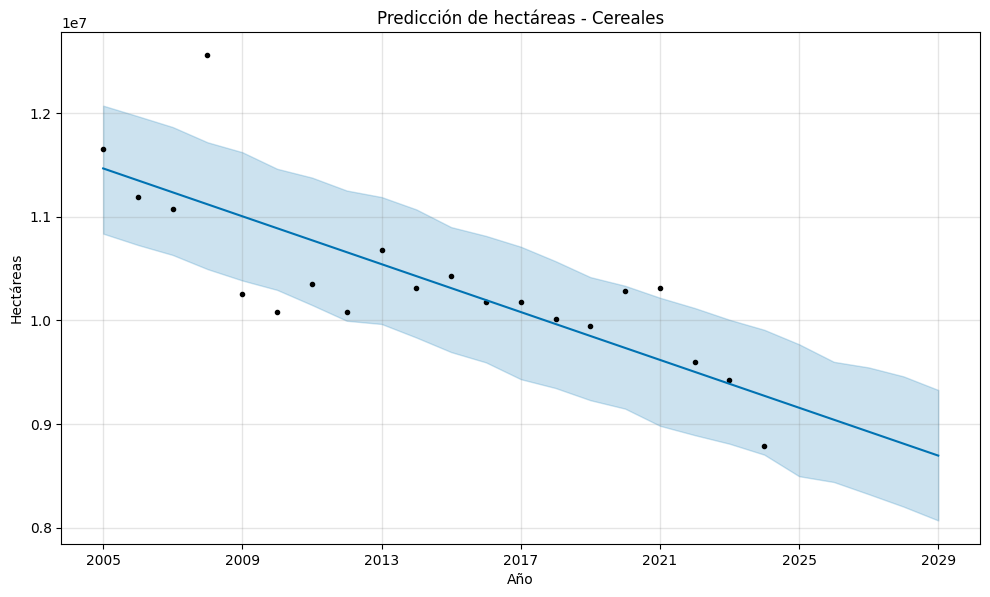

In [7]:
#Modelo predictivo para el trigo
df_prophet_trigo = df_modelo[
    df_modelo["Cultivo"].isin(cereales)
].groupby("Anio").agg({
    "Hectareas": "sum",
    "Temp_media": "mean",
    "Precipitacion": "mean"
}).reset_index()

df_prophet_trigo.columns = ["ds", "y", "Temp_media", "Precipitacion"]
df_prophet_trigo["ds"] = pd.to_datetime(df_prophet_trigo["ds"], format="%Y")

modelo_trigo = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    interval_width=0.80
)

modelo_trigo.add_regressor("Temp_media")
modelo_trigo.add_regressor("Precipitacion")
modelo_trigo.fit(df_prophet_trigo)

futuro_trigo = modelo_trigo.make_future_dataframe(periods=5, freq="YE")
futuro_trigo["Temp_media"] = df_prophet_trigo["Temp_media"].mean()
futuro_trigo["Precipitacion"] = df_prophet_trigo["Precipitacion"].mean()

prediccion_trigo = modelo_trigo.predict(futuro_trigo)

y_real = df_prophet_trigo["y"].values
y_pred = prediccion_trigo[prediccion_trigo["ds"].isin(df_prophet_trigo["ds"])]["yhat"].values

print(f"R²:  {r2_score(y_real, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_real, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_real, y_pred)):.2f}")

modelo_trigo.plot(prediccion_trigo)
plt.title("Predicción de hectáreas - Cereales")
plt.xlabel("Año")
plt.ylabel("Hectáreas")
plt.show()

21:59:40 - cmdstanpy - INFO - Chain [1] start processing
21:59:40 - cmdstanpy - INFO - Chain [1] done processing


R²:  0.993
MAE: 9777.73
RMSE: 14483.51


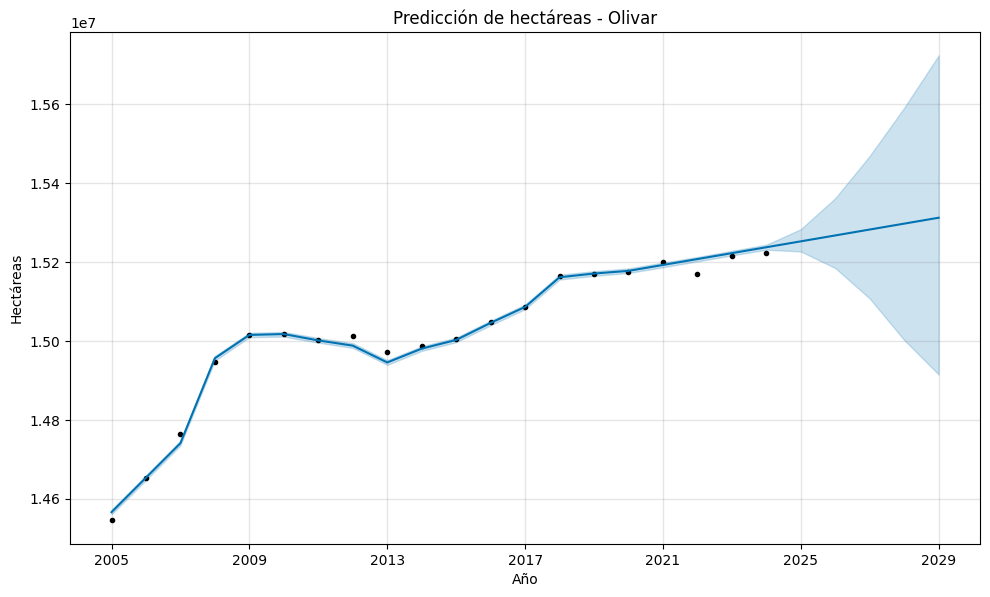

In [8]:
#Modelo predictivo para el olivar
df_prophet_olivar = df_modelo[
    df_modelo["Cultivo"].isin(aceitunas)
].groupby("Anio").agg({
    "Hectareas": "sum",
    "Temp_media": "mean",
    "Precipitacion": "mean"
}).reset_index()

df_prophet_olivar.columns = ["ds", "y", "Temp_media", "Precipitacion"]
df_prophet_olivar["ds"] = pd.to_datetime(df_prophet_olivar["ds"], format="%Y")

modelo_olivar = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    interval_width=0.80
)

modelo_olivar.add_regressor("Temp_media")
modelo_olivar.add_regressor("Precipitacion")
modelo_olivar.fit(df_prophet_olivar)

futuro_olivar = modelo_olivar.make_future_dataframe(periods=5, freq="YE")
futuro_olivar["Temp_media"] = df_prophet_olivar["Temp_media"].mean()
futuro_olivar["Precipitacion"] = df_prophet_olivar["Precipitacion"].mean()

prediccion_olivar = modelo_olivar.predict(futuro_olivar)

y_real = df_prophet_olivar["y"].values
y_pred = prediccion_olivar[prediccion_olivar["ds"].isin(df_prophet_olivar["ds"])]["yhat"].values

print(f"R²:  {r2_score(y_real, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_real, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_real, y_pred)):.2f}")

modelo_olivar.plot(prediccion_olivar)
plt.title("Predicción de hectáreas - Olivar")
plt.xlabel("Año")
plt.ylabel("Hectáreas")
plt.show()

21:59:50 - cmdstanpy - INFO - Chain [1] start processing
21:59:50 - cmdstanpy - INFO - Chain [1] done processing


R²:  0.682
MAE: 39257.90
RMSE: 48341.78


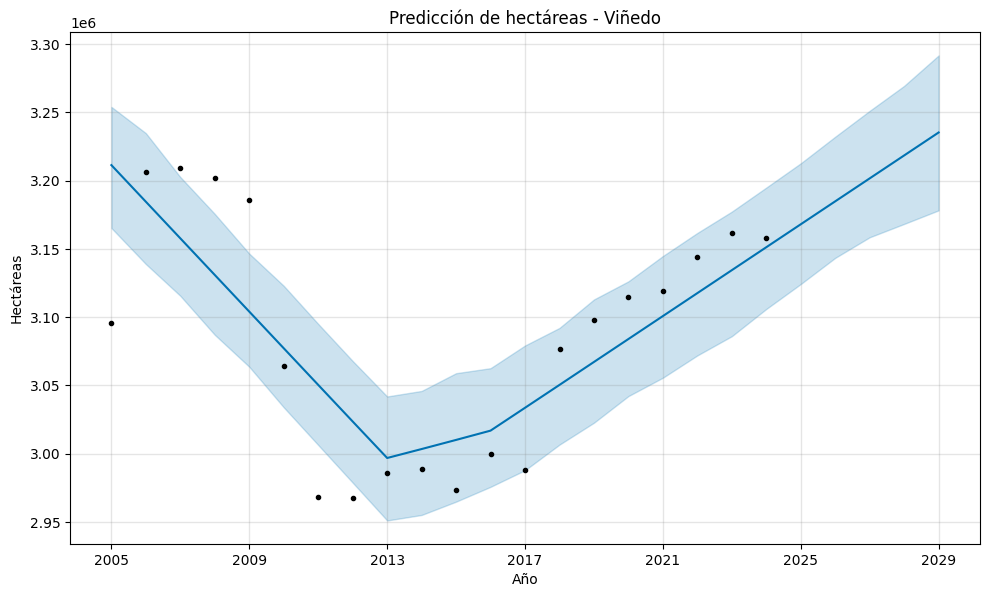

In [9]:
#Modelo predictivo para los viñedo
df_prophet_vino = df_modelo[
    df_modelo["Cultivo"].isin(vinos)
].groupby("Anio").agg({
    "Hectareas": "sum",
    "Temp_media": "mean",
    "Precipitacion": "mean"
}).reset_index()

df_prophet_vino.columns = ["ds", "y", "Temp_media", "Precipitacion"]
df_prophet_vino["ds"] = pd.to_datetime(df_prophet_vino["ds"], format="%Y")

modelo_vino = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    interval_width=0.80
)


modelo_vino.add_regressor("Temp_media")
modelo_vino.add_regressor("Precipitacion")
modelo_vino.fit(df_prophet_vino)

futuro_vino = modelo_vino.make_future_dataframe(periods=5, freq="YE")
futuro_vino["Temp_media"] = df_prophet_vino["Temp_media"].mean()
futuro_vino["Precipitacion"] = df_prophet_vino["Precipitacion"].mean()

prediccion_vino = modelo_vino.predict(futuro_vino)

y_real = df_prophet_vino["y"].values
y_pred = prediccion_vino[prediccion_vino["ds"].isin(df_prophet_vino["ds"])]["yhat"].values

print(f"R²:  {r2_score(y_real, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_real, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_real, y_pred)):.2f}")

modelo_vino.plot(prediccion_vino)
plt.title("Predicción de hectáreas - Viñedo")
plt.xlabel("Año")
plt.ylabel("Hectáreas")
plt.show()

21:59:58 - cmdstanpy - INFO - Chain [1] start processing
21:59:58 - cmdstanpy - INFO - Chain [1] done processing


R²:  0.865
MAE: 54755.35
RMSE: 71357.07


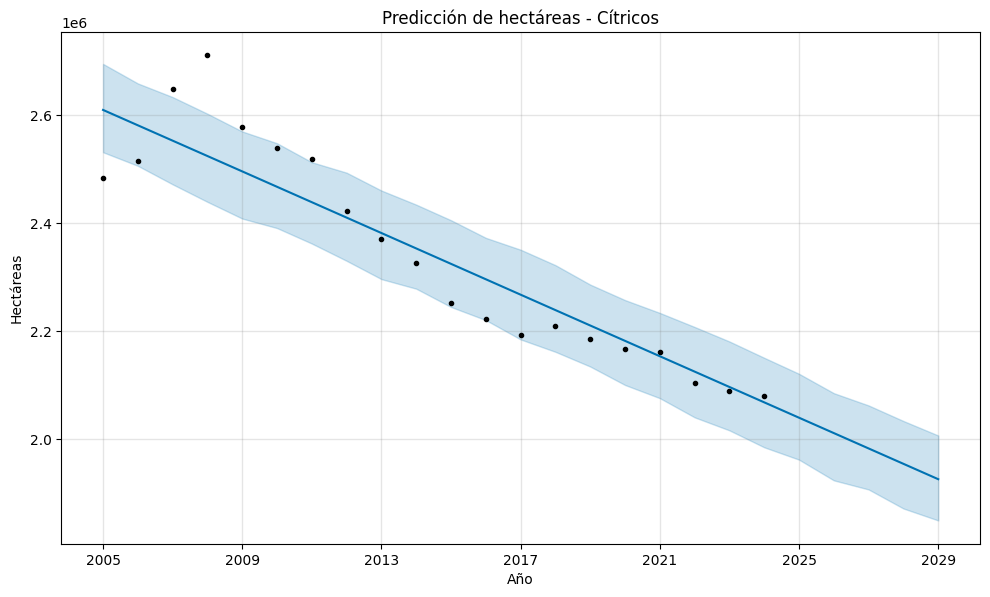

In [10]:
#Modelo predictivo para los cítricos.
df_prophet_citricos = df_modelo[
    df_modelo["Cultivo"].isin(citricos)
].groupby("Anio").agg({
    "Hectareas": "sum",
    "Temp_media": "mean",
    "Precipitacion": "mean"
}).reset_index()

df_prophet_citricos.columns = ["ds", "y", "Temp_media", "Precipitacion"]
df_prophet_citricos["ds"] = pd.to_datetime(df_prophet_citricos["ds"], format="%Y")

modelo_citricos = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    changepoint_prior_scale=0.05,
    interval_width=0.80
)

modelo_citricos.add_regressor("Temp_media")
modelo_citricos.add_regressor("Precipitacion")
modelo_citricos.fit(df_prophet_citricos)

futuro_citricos = modelo_citricos.make_future_dataframe(periods=5, freq="YE")
futuro_citricos["Temp_media"] = df_prophet_citricos["Temp_media"].mean()
futuro_citricos["Precipitacion"] = df_prophet_citricos["Precipitacion"].mean()

prediccion_citricos = modelo_citricos.predict(futuro_citricos)

y_real = df_prophet_citricos["y"].values
y_pred = prediccion_citricos[prediccion_citricos["ds"].isin(df_prophet_citricos["ds"])]["yhat"].values

print(f"R²:  {r2_score(y_real, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_real, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_real, y_pred)):.2f}")

modelo_citricos.plot(prediccion_citricos)
plt.title("Predicción de hectáreas - Cítricos")
plt.xlabel("Año")
plt.ylabel("Hectáreas")
plt.show()

#### **Cereales**
R² = 0.595. Tendencia bajista sostenida, pasando de 12 millones de hectáreas en 2005 a menos de 10 millones en 2024, liderada por la caída de la Cebada de 2 carreras. Prophet predice que la superficie seguirá reduciéndose hasta 2029.

#### **Olivar**
R² = 0.993. El mejor modelo del análisis. Tendencia alcista muy consistente y predecible, reflejo de la expansión del olivar intensivo en España. Prophet predice que la superficie seguirá creciendo aunque con mayor incertidumbre a partir de 2025.

#### **Viñedo**
R² = 0.682. Patrón en forma de V: caída hasta 2012 coincidiendo con la crisis económica y recuperación sostenida desde entonces. Prophet predice que la tendencia alcista continuará hasta 2029.

#### **Cítricos**
R² = 0.865. Tendencia bajista muy consistente, perdiendo más de 400.000 hectáreas desde 2005. Prophet predice que la reducción de superficie continuará hasta 2029, lo que podría estar relacionado con el aumento de temperaturas y la competencia de otros países productores.

 Cultivo    R²       MAE      RMSE    Tendencia
Cereales 0.595 348837.37 497849.10      Bajista
  Olivar 0.993   9777.73  14483.51      Alcista
  Viñedo 0.682  39257.90  48341.78 Recuperación
Cítricos 0.865  54755.35  71357.07      Bajista


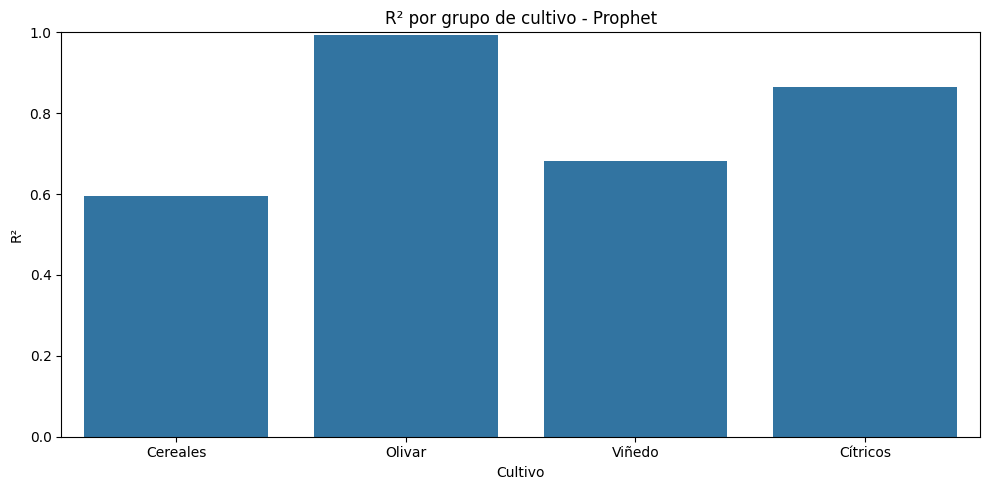

In [11]:
#Comparativa de resultados
comparativa = pd.DataFrame({
    "Cultivo": ["Cereales", "Olivar", "Viñedo", "Cítricos"],
    "R²": [0.595, 0.993, 0.682, 0.865],
    "MAE": [348837.37, 9777.73, 39257.90, 54755.35],
    "RMSE": [497849.10, 14483.51, 48341.78, 71357.07],
    "Tendencia": ["Bajista", "Alcista", "Recuperación", "Bajista"]
})

print(comparativa.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=comparativa, x="Cultivo", y="R²")
plt.title("R² por grupo de cultivo - Prophet")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

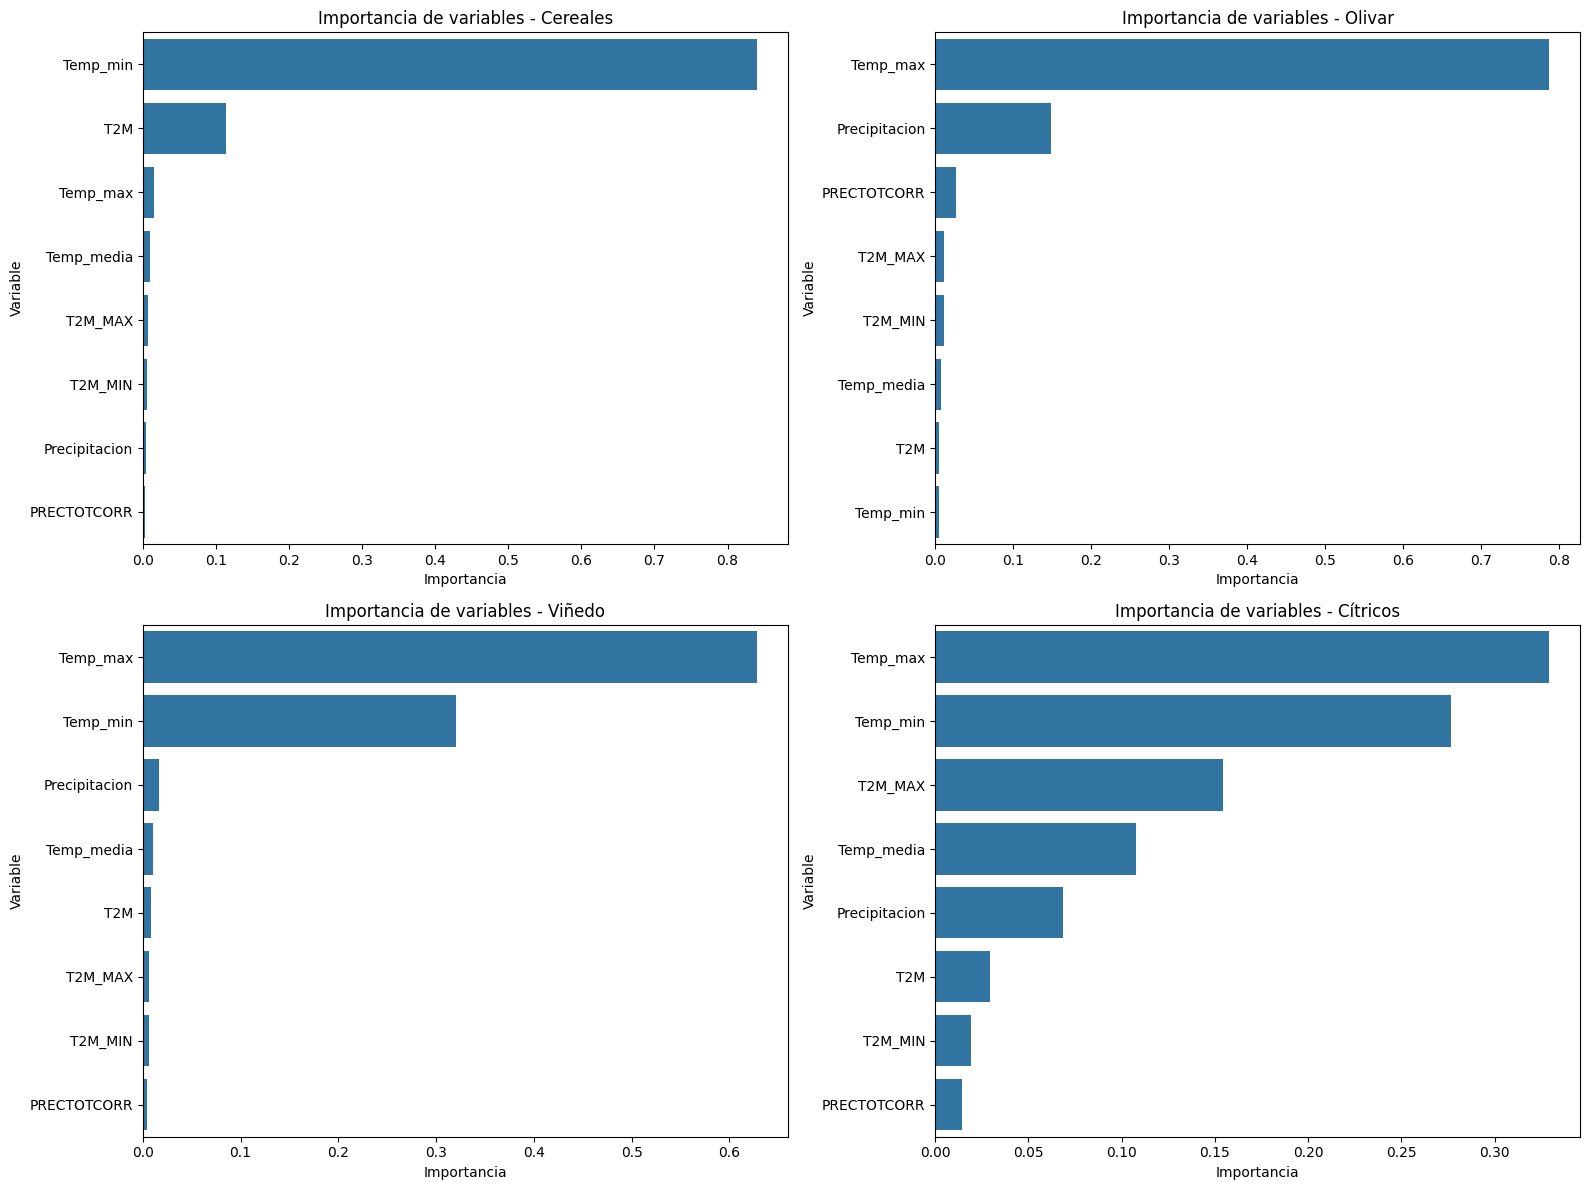

In [12]:
#Importancia de variables - Random Forest

features = ["Temp_media", "Temp_min", "Temp_max", "Precipitacion",
            "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN"]

grupos = {
    "Cereales": cereales,
    "Olivar": aceitunas,
    "Viñedo": vinos,
    "Cítricos": citricos
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (nombre, cultivos_grupo) in enumerate(grupos.items()):
    df_grupo = df_modelo[df_modelo["Cultivo"].isin(cultivos_grupo)].copy()
    
    X = df_grupo[features]
    y = df_grupo["Hectareas"].values
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    
    importancia = pd.DataFrame({
        "Variable": features,
        "Importancia": rf.feature_importances_
    }).sort_values("Importancia", ascending=False)
    
    sns.barplot(data=importancia, x="Importancia", y="Variable", ax=axes[i])
    axes[i].set_title(f"Importancia de variables - {nombre}")

plt.tight_layout()
plt.show()

#### **Importancia de variables climáticas - Random Forest**

El análisis de importancia de variables mediante Random Forest revela que cada cultivo tiene su propio factor climático crítico:

**Cereales**: la temperatura mínima (Temp_min) domina con una importancia de 0.84. Las heladas son el factor más determinante para la superficie de cereales en España, lo que tiene sentido agronómico dado que las heladas tardías pueden destruir las cosechas en fase de floración.

**Olivar**: la temperatura máxima (Temp_max) domina con 0.78. El calor extremo es el factor más crítico para el olivar, coherente con su expansión en zonas cálidas como Jaén y su resistencia a la sequía.

**Viñedo**: combinación de temperatura máxima (0.63) y mínima (0.32). La vid es el cultivo más sensible a todo el rango térmico, necesitando calor suficiente para madurar pero siendo vulnerable tanto a heladas como a calor extremo.

**Cítricos**: el impacto está más repartido entre Temp_max, Temp_min y T2M_MAX, confirmando que los cítricos son sensibles a todo el espectro de temperatura. La precipitación también tiene un peso relevante en comparación con otros cultivos.

**Conclusión clave**: las variables de temperatura AEMET son sistemáticamente más importantes que las de NASA en todos los cultivos, confirmando que los datos provinciales de AEMET son más representativos para el análisis agrícola en España.

#### **Conclusiones**

##### Sobre el modelo predictivo
Se desarrollaron 4 modelos de serie temporal con Prophet, uno por grupo de cultivo, incorporando temperatura media y precipitación como regresores externos. Los resultados son sólidos en todos los casos, destacando el olivar (R²=0.993) y los cítricos (R²=0.865).

##### Tendencias identificadas
- **Cereales**: superficie en descenso sostenido, liderado por la caída de la cebada
- **Olivar**: expansión continua del olivar intensivo en España
- **Viñedo**: recuperación tras la caída de la crisis económica de 2008-2012
- **Cítricos**: reducción progresiva de superficie, posiblemente relacionada con el aumento de temperaturas y la competencia internacional

##### Factores climáticos críticos por cultivo
- Cereales → temperatura mínima (heladas)
- Olivar → temperatura máxima (calor extremo)
- Viñedo → rango térmico completo
- Cítricos → temperatura en todos sus rangos

##### Limitaciones del estudio
- Solo 4 estaciones climáticas de referencia (Valladolid, Valencia, Jaén y La Rioja)
- Los modelos predicen tendencias pero no incorporan factores socioeconómicos como precios de mercado o política agraria

##### Implicación para el sector
Con el calentamiento global acelerándose, los cultivos más sensibles a la temperatura máxima (olivar y cítricos) verán alteradas sus condiciones óptimas de cultivo, mientras que los cereales serán más vulnerables a la reducción de heladas invernales necesarias para su desarrollo.